En este NoteBook el objetivo comenzara realizando la carga y limpieza de los datos, aplicarle una especide de estandarizacion, entender su comportamiento visual antes de realizar modelar, por lo que estara compuesto de lo siguiente:
    - **Importaciones:** Carga de librerias base
    - **Carga de datos:** **"pd.read_parquet()"** para leer las 6 series de mercado (como lo son **brent**, **wti**, **eurusd**) y las 3 series del indice de precios (HICP)
    - **Formato de fechas:** Convierte inmediatamente la columna **date** a un objeto **datatime** de Pandas y ordena los DataFrames cronologicamente.
    - **Visualizacion:** Grafica la serie daria del **brent** junto con la serie mensual **hicp_transport_fuels_it** para identificar los retrasos (lags) visuales en la trasmision de precios.

## El reto de la frecuencia: Dario vs Mensual


Es un problema clasico de **Nowcasting** los mercados operan a diario (incluyendo calendarios festivos por la parte de estados unidos y el BCE), pero la inflacion se reporta mensualmente. Para conciliar esto, existen dos caminos analiticos:
- **Agrupacion mensual:** Consiste en agrupar los datos diarios del mercado extrayendo la media matematica de todos los dias habiles de un mes. Esto colapsa la serie diaria a una frecuencia mensual, permitiendo un mapeo directo en relacion 1:1 con el indice de precios al consumidor.
- **Nowcasting Intra-mes (El modelo avanzado):** Consiste en simular que se encuentra en el dia 15 del mes. Debe usar los 15 dias ya cotizados y proyectar el resto del mes (Parte 1 del proyecto) para luego predecir el impacto en el indice mensual (Parte 2 del proyecto)

## Agrupacion mensual (Baseline)

El problema principal que existe es la desalineacion de frecuencias: los mercados operan y cambian de precio todos los dias habiles, pero la inflacion (HICP) es un unico numero que resume todo el mes

Al aplicar un **promedio mensual simple**, lo que se realiza es tomar todos los precios diarios de un mes en especifico (por ejemplo, todos los dias habiles de enero para el **brent**) y calcular su media matematica. Esto colapsa la serie diaria en una serie mensual. De esta forma, se puede emparejar directamente el "promedio del mercado de enero" con la "inflacion reportada para enero", creando un dataset tabular clasico de 1 a 1 perfecto para modelos como regresiones o arboles de decision. 

Para este primer Jupyter notebook se hara uso del archivo **energy_panel.csv** que ya contiene todas las series aplicadas, lo que facilita muchisimo la manipulacion con Pandas.

In [2]:
# ==========================================
# 1. IMPORTS AND DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Visual configurations for the plots 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

print("Loading the energy data panel...")
# Read the CSV file with all series
df = pd.read_csv('../data/energy_panel.csv')

# Convert the date column to a pandas datetime object
df['date'] = pd.to_datetime(df['date'])

Loading the energy data panel...


In [4]:
# ==========================================
# 2. PIVOT AND ALIGNMENT (THE MONTHLY BASELINE)
# ==========================================
# Pivot for each 'series_id' be a distinct column
df_wide = df.pivot(index='date', columns='series_id', values='value')

# Define which series are our market series (daily) and which are HICP (monthly)
market_series = ['brent', 'wti', 'us_gasoline_spot', 'us_diesel_spot', 'heating_oil_ny', 'eurusd']
hicp_series = ['hicp_transport_fuels_it', 'hicp_heating_it', 'hicp_headline_it']

# Separate the market quotes
df_market = df_wide[market_series].dropna(how='all')

# THE BASELINE TRICK: Group the daily data by calculating the monthly average
# 'MS' means Month Start (assigns the average to the 1st day of the month to align with HICP)
print("Grouping daily data into monthly averages...")
df_market_monthly = df_market.resample('MS').mean()

# Separate the HICP inflation series (already in monthly format on the 1st day of each month)
df_hicp = df_wide[hicp_series].dropna(how='all')

# Merge the monthlyized market data and HICP using date as index
df_baseline = pd.merge(df_market_monthly, df_hicp, left_index=True, right_index=True, how='inner')

print(f"\nDimensions of the aligned dataset (Monthly): {df_baseline.shape}")
display(df_baseline.head())

Grouping daily data into monthly averages...

Dimensions of the aligned dataset (Monthly): (360, 9)


series_id,brent,wti,us_gasoline_spot,us_diesel_spot,heating_oil_ny,eurusd,hicp_transport_fuels_it,hicp_heating_it,hicp_headline_it
date,,,,,,,,,
1996-01-01,17.853182,18.854545,0.494227,NaN,0.555000,NaN,59.0,54.5,67.5
1996-02-01,17.999048,19.093500,0.514400,NaN,0.613600,NaN,58.8,54.6,67.8
1996-03-01,19.851905,21.332381,0.581381,NaN,0.656524,NaN,59.4,54.8,68.0
1996-04-01,20.900500,23.497143,0.660000,NaN,0.676190,NaN,60.4,55.8,68.3
1996-05-01,19.154762,21.165455,0.626909,NaN,0.575909,NaN,60.1,55.2,68.5


- **1. Pivoteo:** Pasa los datos de un formato "largo" (Donde todas las variables estan en una sola columna) a un formato "ancho" (donde el **brent**, el **wti**, etc, tienen su propia columna). Esto es vital para que un modelo de Machine Learning entienda las caracteristicas (**Features**)
- **2. resample('MS').mean()** Con esta funcion de Pandas, se toman todos los valores diarios, los agrupa por mes de calendario y saca el promedio, etiquetando el resultado en el dia 1 de ese mes **(MS = Month Start)**. Como el HICP tambien esta etiquetado el dia 1 del mes, nos permite unir ambos datasets a la perfeccion con un merge.
- **3. Consolidado en base a las dimensiones:** Se consolidaron perfectamente 360 registros lo que significa que hay exactamente 30 años de historia mensual

# Representacion Visual

Mediante el uso de herramientas analiticas de Python como Matpotlib. Al graficar estas dos series, se enfrenta a un reto visual: el precio del curdo **brent** se mide en dolares por barril, mientras que la inflacion de combustibles **(hicp_transport_fuels_it)** es un indice donde el año base 2025 equivale a 100

Por lo que si se grafica ambos en el eje Y, las escalas no coincidiran y se perdera la visualizacion, no tendra sentido. La practica ideal para este caso es en utilziar un grafico de doble eje **(twin axes)**

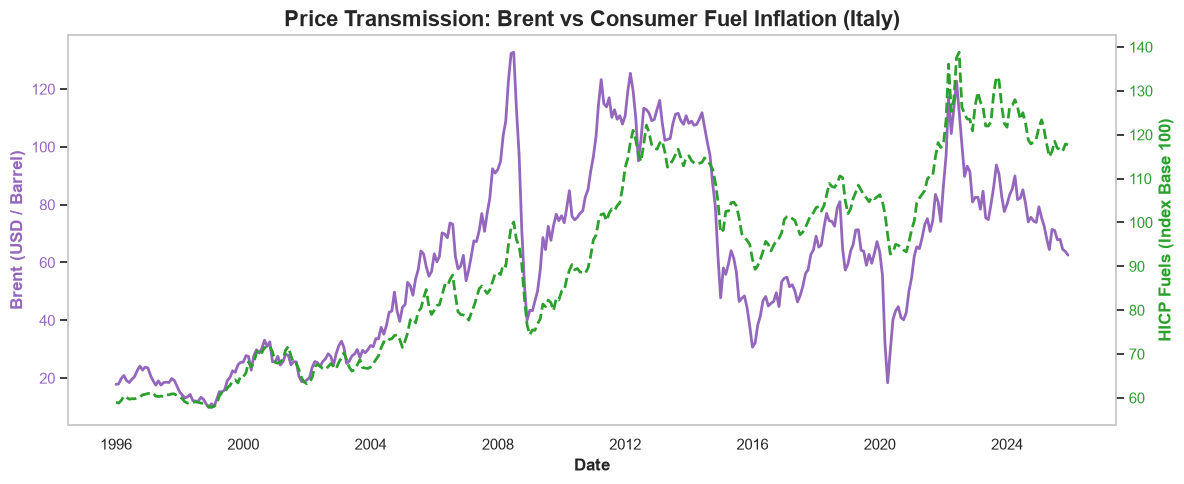

In [8]:
# ==========================================
# 3. VISUALIZATION: BRENT VS INFLATION (TRANSPORT FUELS ITALY)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 5))

# Configuration of the primary Y-axis (Left) for Brent
color_brent = 'tab:purple'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Brent (USD / Barrel)', color=color_brent, fontweight='bold')
ax1.plot(df_baseline.index, df_baseline['brent'], color=color_brent, label='Brent Crude', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_brent)
ax1.grid(False) # Turn off the grid to avoid visual noise with two axes

# For instance a second Y-axis (Right) that shares the same X-axis
ax2 = ax1.twinx()  

# Configure the secondary Y-axis for the HICP index
color_hicp = 'tab:green'
ax2.set_ylabel('HICP Fuels (Index Base 100)', color=color_hicp, fontweight='bold')
ax2.plot(df_baseline.index, df_baseline['hicp_transport_fuels_it'], color=color_hicp, label='HICP Transport (Italy)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_hicp)
ax2.grid(False)

# Legend configuration
plt.title('Price Transmission: Brent vs Consumer Fuel Inflation (Italy)', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

En la grfica se puede observar detenidamente dentro de los mas altos picos historicos de los años 2008 y aproximadamente 2022 en la linea del **Brent (Morada)** se mueve y alcanza su punto maximo primero, y la linea del **HICP (Verde)** reacciona despues. Este es el efecto de los margenes de refinacion, impuestos y tiempos de distribucion que son los factores que podrian retrasar o amortiguan la transmision del precio hacia el consumidor final.

## Que son los Rezagos temporales (Lag Features)

Algoritmos tabulares como lo son **(Regression, Random Forest, LightGBM)** leen los datos fila por fila y no tienen un concepto nativo del "tiempo". Si el objetivo es predecir la inflacion de Marzo por ejmplo, no basta solo con darle el prcio del crudo de ese mes

- **El concepto:** Un Lag feature es simplemente el valor de una variable en un periodo anterior
- **La utilidad:** Nos permite poner en fila correspondiente a "Marzo", los precios del mercado que ocurrieron en "Febrero" (Lag 1) o "Enero" (Lag 2)
- **El Beneficio:** Gracias a esto el modelo podria aprender las reglas matematicas como "Si el crudo subio hace dos meses, la inflacion de transporte subira este mes"

Para la creacion de Rezagos esta la ayuda de la libreria de Pandas con la funcion **.shift()**. Como inicios se opto por crear rezagos de 1,2 y 3 meses para todas las variables del mercado.

In [9]:
# ==========================================
# 4. FEATURE ENGINEERING: LAGS
# ==========================================
# Variables defined from the market data that we will use to create lagged features
market_features = ['brent', 'wti', 'us_gasoline_spot', 'us_diesel_spot', 'heating_oil_ny', 'eurusd']

# Create a copy of the baseline dataset to avoid modifying the original
df_features = df_baseline.copy()

print("Generating temporal lags of 1, 2 and 3 months...")

# Iterate over each variable to create its lagged versions
for col in market_features:
    df_features[f'{col}_lag1'] = df_features[col].shift(1) # Value from 1 month ago
    df_features[f'{col}_lag2'] = df_features[col].shift(2) # Value from 2 months ago
    df_features[f'{col}_lag3'] = df_features[col].shift(3) # Value from 3 months ago

# After shifting the data, the first 3 rows (January, February and March of 1996) 
# will be left without past values (NaN). We remove them so the model doesn't fail.
df_features.dropna(inplace=True)

print(f"Dimensions of the dataset with lags: {df_features.shape}")
display(df_features.head())

Generating temporal lags of 1, 2 and 3 months...
Dimensions of the dataset with lags: (232, 27)


series_id,brent,wti,us_gasoline_spot,us_diesel_spot,heating_oil_ny,eurusd,hicp_transport_fuels_it,hicp_heating_it,hicp_headline_it,brent_lag1,...,us_gasoline_spot_lag3,us_diesel_spot_lag1,us_diesel_spot_lag2,us_diesel_spot_lag3,heating_oil_ny_lag1,heating_oil_ny_lag2,heating_oil_ny_lag3,eurusd_lag1,eurusd_lag2,eurusd_lag3
date,,,,,,,,,,,,,,,,,,,,,
2006-09-01,61.958571,63.798000,1.560000,1.788950,1.699600,1.272743,83.3,88.8,86.2,73.230435,...,2.122818,2.233304,2.231350,2.108077,1.983739,1.935526,1.924909,1.281130,1.268367,1.264995
2006-10-01,57.808182,58.893182,1.510227,1.784182,1.648000,1.261105,79.6,86.0,86.3,61.958571,...,2.270368,1.788950,2.233304,2.231350,1.699600,1.983739,1.935526,1.272743,1.281130,1.268367
2006-11-01,58.761364,59.082500,1.562950,1.796762,1.648350,1.288141,79.0,85.5,86.4,57.808182,...,2.001391,1.784182,1.788950,2.233304,1.648000,1.699600,1.983739,1.261105,1.272743,1.281130
2006-12-01,62.472105,61.959000,1.596850,1.790700,1.683800,1.321279,78.9,85.3,86.5,58.761364,...,1.560000,1.796762,1.784182,1.788950,1.648350,1.648000,1.699600,1.288141,1.261105,1.272743
2007-01-01,53.681429,54.506190,1.410286,1.638857,1.527619,1.299864,78.7,83.7,85.6,62.472105,...,1.510227,1.790700,1.796762,1.784182,1.683800,1.648350,1.648000,1.321279,1.288141,1.261105


## Separacion de variables (X and y)

Ya una vez organizada la informacion de data, el objetivo principal es predecir los indices mensuales. Para esto se realiza una pipline comun y corriente para este primer modelo, en el cual se encontrara enfocado para la inflacion de combustibles de trasnporte, ya que es la categoria que reacciona mas rapido a los cambios en el dataset brent

- **Matriz de caracteristicas (Features X):** Contendra los precios promedios del mes actual y sus respectivos rezagos. Esta excluido estrictamente cualquier metrica de inflacion de esta matriz para evitar la fuga de datos (Data leakage).
- **Varible objetivo (Target y):** Sera exlusivamente la columna **hicp_transport_fuels_it** en el que formalmente se estara construyendo una funcion predictiva en donde la estiamcion en el tiempo t se estaria definiendo como:  $\hat{y}_t = f(X_t, X_{t-1}, X_{t-2}, X_{t-3})$

**NOTE:** Dado que es un caso de series temporales y por la informacion se puede obtener que del "Pasado se puede predecir el futuro" hacer uso del **train_test_split** aleatorio en el que mezcla los datos no es ideal para este trabajo.

Como **Baseline** se tomara un modelo robusto conocido como la **Ridge Regression (Penalizacion lineal)**, por el hecho de haber creado los **lags de tiempo los rezagos**, esta inmerza una alta **colinealidad** (ej: El precio del pretolio de hace 1 mes se parece demasiado al de hace 2 meses) (la correlacion que existe entre variables predictoras o independientes, de modo que expresan una relacion lineal en el modelo de regresion, lo que le impide predecir el valor de la variable dependiente).

Un modelo convencional colapsaria, pero con la Ridge Regression logra manejar este tema de una manera optima, en base de una metrica de error **(RMSE y MAE)** para luego intentarla superar con otros tipos de algoritmos

In [11]:
# ==========================================
# 5. PREPARATION AND TRAINING (BASELINE)
# ==========================================
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("Preparing variables and separating chronologically...")

# 1. Define the target variable
target = 'hicp_transport_fuels_it'

# 2. Separate X and y (excluding all inflation columns from X)
X = df_features.drop(columns=['hicp_transport_fuels_it', 'hicp_heating_it', 'hicp_headline_it'])
y = df_features[target]

# 3. Chronological Split (80% Train, 20% Test)
train_size = int(len(df_features) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Period of Training: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} months)")
print(f"Period of Testing: {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} months)")

# 4. Training the Model
print("\nTraining Ridge Regression (Baseline)...")
model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train, y_train)

# 5. Prediction and Evaluation
pred = model_ridge.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"\n--- PERFORMANCE OF THE BASELINE MODEL ---")
print(f"MAE  (Mean Absolute Error): {mae:.2f} index points")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} index points")

Preparing variables and separating chronologically...
Period of Training: 2006-09-01 to 2022-01-01 (185 months)
Period of Testing: 2022-02-01 to 2025-12-01 (47 months)

Training Ridge Regression (Baseline)...

--- PERFORMANCE OF THE BASELINE MODEL ---
MAE  (Mean Absolute Error): 8.21 index points
RMSE (Root Mean Squared Error): 8.62 index points


Con las metricas de obtenias del **MAE de 8.21** y **RMSE de 8.62** para interpretar desde la perspectiva de negocio

- El indice de HICP tiene una base de 100 años (año 2015). En el momento de que se equivoque por 8.21 puntos significa que la predicion esta desviada en un nivel considerable, especialmente para una metrica de inflacion en donde se realizaria por decimas de porcentaje
- Esto ocurre dado que la **Ridge Regression** asume una relacion lineal perfecta. Sin embargo los mercados energeticos sufren del famoso efecto "Rockets and feathers" cuando el brent sube, las gasolineras suben los precios como un cohete; pero cuando el brent baja, los precios caen lentamente como una pluma. **Un modelo lineal simple no logra capturar completamente esta asimetria**

# Revision con modelo de arboles escalamiento hacia el LightGBM

Para capturar relaciones mas complejas (no lineales) y en general los umbrales de los precios, los modelos basados en arboles de deciciones podrian ser una version mejor adaptada

Dado que **LightGBM** es considerablemente potente y se esta trabajando con un dataset pequeño (alrededor de 200 filas para entrenar) puede que este modelo sufra de **overfitting**. Por ende se configuran los hiperparametros mas conservadores (arboles poco profundos)

In [12]:
# ==========================================
# 6. TRAINING ADVANCED MODEL (LightGBM)
# ==========================================
from lightgbm import LGBMRegressor

print("Training LightGBM model for non-linear relationships...")

# Configuration of conservative parameters to avoid overfitting in small datasets
modelo_lgb = LGBMRegressor(
    n_estimators=100,      # Quantity of trees
    max_depth=4,           # Shallow trees
    learning_rate=0.05,    # Slow learning
    random_state=42,
    extra_trees=True       # Adds randomness, ideal for small datasets
)

modelo_lgb.fit(X_train, y_train)

# Prediction and Evaluation
predicciones_lgb = modelo_lgb.predict(X_test)
mae_lgb = mean_absolute_error(y_test, predicciones_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, predicciones_lgb))

print(f"\n--- PERFORMANCE LIGHTGBM ---")
print(f"MAE  (Mean Absolute Error): {mae_lgb:.2f} points")
print(f"RMSE (Root Mean Squared Error): {rmse_lgb:.2f} points")

Training LightGBM model for non-linear relationships...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1512
[LightGBM] [Info] Number of data points in the train set: 185, number of used features: 24
[LightGBM] [Info] Start training from score 99.716757
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

Los resultados obtenidos a partir del entrenamiento con el modelo LightGBM no muestran ser mas prometedores es mas muestran incluso una deficiencia en el rendimiento obteniendo los puntos de **MAE (Mean Absolute Error): 10.21** y **RMSE (Root Mean Square Error): 10.93**

**Note:** Comenzando desde una base line que fue el uso de una **Ridge Regression** se obtuvo un **MAE de 8.21**. Se busco capturar las non-linealidades con el modelo LigthGBM, pero esto solo temino incrementando el error con un **MAE de 10.21**. Esto comprobo que empiricamente al tener una muestra pequeña (185 meses) y una fuerte tendencia inflacionaria en el set de prueba (post 2022), un modelo lineal generaliza y extrapola mucho mejor que un modelo basado en arboles